# 03 — Validation: Gender Accuracy, Coverage Audit & SCM Triangulation

This notebook establishes pipeline validity before hypothesis testing through three checks:
- **A. Gender assignment accuracy** — Qwen gender labels vs museum text ground truth
- **B. SADCAT coverage audit** — dictionary hit rate and descriptor density
- **C. SCM triangulation** — VLM-derived scores vs museum-text-derived scores

In [24]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

# ── Config ──
DB_PATH = "/home/agrupa-lab/agrupa/agrupa.sqlite"
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {"Male": "#6dc985", "Female": "#4f2478", "Unknown": "#888780"}
CTX_COLORS = {"religious": "#660033", "secular": "#B8C4BB"}
DPI = 300

KEEP_TIPOS = (
    'Cartón para tapiz', 'Cuadro Boceto', 'Cuadro con marco integrado',
    'Díptico', 'Tríptico', 'Pequeño retrato', 'Pintura',
    'Pintura de retablo', 'Pintura mural', 'Puerta de sagrario',
)

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    print(f"  Saved: ../figures/{name}.png")

In [25]:
# ── Load all data ──
conn = sqlite3.connect(DB_PATH)
placeholders = ','.join(['?'] * len(KEEP_TIPOS))

# Qwen figures
figures = pd.read_sql_query(f"""
    SELECT f.*, a.is_religious, a.is_fauna, a.titulo
    FROM figures_m f
    JOIN artwork a ON f.cat_no = a.cat_no
    WHERE a.tipo_objeto IN ({placeholders})
""", conn, params=KEEP_TIPOS)

# Museum descriptors
museum_desc = pd.read_sql_query("SELECT * FROM artwork_descriptor", conn)

# Museum SADCAT scores
museum_sadcat = pd.read_sql_query("SELECT * FROM artwork_sadcat", conn)

conn.close()

print(f"Qwen figures: {len(figures)}")
print(f"Museum descriptors: {len(museum_desc)}")
print(f"Museum SADCAT scores: {len(museum_sadcat)}")

Qwen figures: 19033
Museum descriptors: 2772032
Museum SADCAT scores: 6888


---
## A. Gender Assignment Accuracy

We extract gender ground truth from museum descriptions using Spanish-language markers,
then compare against Qwen's gender assignments at the artwork level.

In [26]:
import re

# ── A1. Extract gender signals from museum descriptions ──
# Spanish gender markers
FEMALE_MARKERS = [
    r'\bvirgen\b', r'\bvírgenes\b', r'\bmadonna\b',
    r'\bsanta\b', r'\bsantas\b',
    r'\breina\b', r'\breinas\b',
    r'\bdiosa\b', r'\bdiosas\b',
    r'\bmujer\b', r'\bmujeres\b',
    r'\bdama\b', r'\bdamas\b',
    r'\bniña\b', r'\bniñas\b',
    r'\binfanta\b',
    r'\bmaría\b', r'\bmadalena\b', r'\bmagdalena\b',
    r'\bjudith\b', r'\bsusana\b', r'\beva\b',
    r'\bvenus\b', r'\bflora\b', r'\bdiana\b', r'\bjuno\b',
    r'\bproserpina\b', r'\bceres\b', r'\bminerva\b',
    r'\bheroína\b',
]

MALE_MARKERS = [
    r'\bsan\b', r'\bsanto\b', r'\bsantos\b',
    r'\brey\b', r'\breyes\b',
    r'\bdios\b',  # careful: not diosa
    r'\bcristo\b', r'\bjesús\b', r'\bjesus\b',
    r'\bhombre\b', r'\bhombres\b',
    r'\bcaballero\b', r'\bcaballeros\b',
    r'\bniño\b', r'\bniños\b',
    r'\binfante\b',
    r'\bpadre\b',
    r'\bapóstol\b', r'\bapóstoles\b',
    r'\bprofeta\b', r'\bprofetas\b',
    r'\bmártir\b',  # can be both but often male in context
    r'\badán\b', r'\bnoé\b', r'\bmoisés\b', r'\bdavid\b',
    r'\bjúpiter\b', r'\bmarte\b', r'\bapolo\b', r'\bbaco\b',
    r'\bhércules\b', r'\bneptuno\b', r'\bvulcano\b',
    r'\bhéroe\b',
]

def extract_museum_gender(text):
    """Extract gender signal from Spanish museum description.
    Returns: 'Female', 'Male', 'Both', or None (ambiguous/no signal)
    """
    if pd.isna(text) or not text:
        return None
    text_lower = text.lower()
    
    has_female = any(re.search(p, text_lower) for p in FEMALE_MARKERS)
    has_male = any(re.search(p, text_lower) for p in MALE_MARKERS)
    
    if has_female and has_male:
        return 'Both'
    elif has_female:
        return 'Female'
    elif has_male:
        return 'Male'
    else:
        return None

# ── A1. FIXED: Aggregate descriptors to artwork level first ──
# artwork_descriptor has one row per word — concatenate back to full text
museum_text = museum_desc.groupby('cat_no')['descriptor'].apply(
    lambda x: ' '.join(x.dropna().astype(str))
).reset_index()
museum_text.columns = ['cat_no', 'full_text']

museum_text['museum_gender'] = museum_text['full_text'].apply(extract_museum_gender)

print("Museum text gender extraction:")
print(museum_text['museum_gender'].value_counts(dropna=False))

Museum text gender extraction:
museum_gender
NaN       2869
Male      1782
Both      1646
Female     591
Name: count, dtype: int64


In [27]:
# ── A2. Also extract gender from artwork titles ──
# Titles often contain very clear gender signals
conn = sqlite3.connect(DB_PATH)
titles = pd.read_sql_query(f"""
    SELECT cat_no, titulo FROM artwork
    WHERE tipo_objeto IN ({placeholders})
""", conn, params=KEEP_TIPOS)
conn.close()

titles['title_gender'] = titles['titulo'].apply(extract_museum_gender)

print("Title-based gender extraction:")
print(titles['title_gender'].value_counts(dropna=False))

Title-based gender extraction:
title_gender
NaN       4494
Male      1712
Female     863
Both       302
Name: count, dtype: int64


In [28]:
# ── A3. Aggregate Qwen gender per artwork ──
# For each artwork, determine the dominant gender from Qwen figures
qwen_gender = figures[figures['gender'].isin(['Male', 'Female'])].copy()

artwork_qwen_gender = qwen_gender.groupby('cat_no')['gender'].apply(
    lambda x: x.value_counts().index[0] if len(x) > 0 else None
).reset_index()
artwork_qwen_gender.columns = ['cat_no', 'qwen_dominant_gender']

# Also compute: does artwork have both genders?
artwork_qwen_both = qwen_gender.groupby('cat_no')['gender'].apply(
    lambda x: 'Both' if set(x) == {'Male', 'Female'} else x.mode().iloc[0]
).reset_index()
artwork_qwen_both.columns = ['cat_no', 'qwen_gender']

print(f"Artworks with Qwen gender: {len(artwork_qwen_both)}")
print(artwork_qwen_both['qwen_gender'].value_counts())

Artworks with Qwen gender: 6093
qwen_gender
Both      2833
Male      2265
Female     995
Name: count, dtype: int64


In [29]:
# ── A4. Compare: museum gender vs Qwen gender ──
# Merge museum gender (from descriptions + titles) with Qwen gender
museum_gender = museum_text[['cat_no', 'museum_gender']].merge(
    titles[['cat_no', 'title_gender']], on='cat_no', how='outer'
)

# Combine: prefer title (more explicit), fall back to descriptor
museum_gender['ground_truth'] = museum_gender['title_gender'].fillna(museum_gender['museum_gender'])

# Merge with Qwen
comparison = museum_gender.merge(artwork_qwen_both, on='cat_no', how='inner')
comparison = comparison[comparison['ground_truth'].notna()].copy()

print(f"Artworks with both museum ground truth AND Qwen gender: {len(comparison)}")
print(f"\nGround truth distribution:")
print(comparison['ground_truth'].value_counts())
print(f"\nQwen gender distribution:")
print(comparison['qwen_gender'].value_counts())

Artworks with both museum ground truth AND Qwen gender: 4301

Ground truth distribution:
ground_truth
Male      2302
Female    1040
Both       959
Name: count, dtype: int64

Qwen gender distribution:
qwen_gender
Both      1994
Male      1598
Female     709
Name: count, dtype: int64


In [30]:
# ── A5. Accuracy metrics ──
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# For accuracy: compare only where both have Male/Female/Both
valid = comparison[
    comparison['ground_truth'].isin(['Male', 'Female', 'Both']) &
    comparison['qwen_gender'].isin(['Male', 'Female', 'Both'])
].copy()

print(f"Valid comparisons: {len(valid)}")

# Exact match accuracy
exact_match = (valid['ground_truth'] == valid['qwen_gender']).mean()
print(f"\nExact match accuracy: {exact_match:.1%}")

# Cohen's Kappa
kappa = cohen_kappa_score(valid['ground_truth'], valid['qwen_gender'])
print(f"Cohen's κ: {kappa:.3f}")

# Classification report
print(f"\nClassification report:")
print(classification_report(valid['ground_truth'], valid['qwen_gender']))

Valid comparisons: 4301

Exact match accuracy: 57.6%
Cohen's κ: 0.355

Classification report:
              precision    recall  f1-score   support

        Both       0.33      0.68      0.44       959
      Female       0.72      0.49      0.59      1040
        Male       0.82      0.57      0.67      2302

    accuracy                           0.58      4301
   macro avg       0.62      0.58      0.57      4301
weighted avg       0.69      0.58      0.60      4301



  Saved: ../figures/V01_gender_confusion_matrix.png


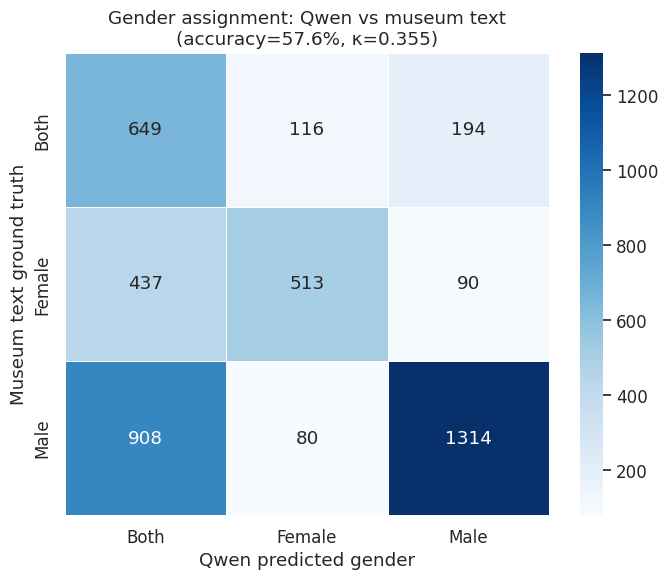

In [31]:
# ── A6. Confusion matrix plot ──
labels = sorted(valid['ground_truth'].unique())
cm = confusion_matrix(valid['ground_truth'], valid['qwen_gender'], labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=labels, yticklabels=labels, ax=ax,
           linewidths=0.5)
ax.set_xlabel('Qwen predicted gender')
ax.set_ylabel('Museum text ground truth')
ax.set_title(f'Gender assignment: Qwen vs museum text\n(accuracy={exact_match:.1%}, κ={kappa:.3f})')

plt.tight_layout()
savefig(fig, 'V01_gender_confusion_matrix')
plt.show()

In [32]:
# ── A7. Accuracy by context (religious vs secular) ──
conn = sqlite3.connect(DB_PATH)
ctx_info = pd.read_sql_query("SELECT cat_no, is_religious FROM artwork", conn)
conn.close()

valid_ctx = valid.merge(ctx_info, on='cat_no')

for ctx_val, ctx_name in [(1, 'Religious'), (0, 'Secular')]:
    sub = valid_ctx[valid_ctx['is_religious'] == ctx_val]
    if len(sub) > 0:
        acc = (sub['ground_truth'] == sub['qwen_gender']).mean()
        k = cohen_kappa_score(sub['ground_truth'], sub['qwen_gender'])
        print(f"{ctx_name} (n={len(sub)}): accuracy={acc:.1%}, κ={k:.3f}")

Religious (n=1996): accuracy=55.6%, κ=0.317
Secular (n=2305): accuracy=59.3%, κ=0.381


---
## B. SADCAT Coverage Audit

Assessing whether VLM-generated descriptors are rich enough for reliable SADCAT scoring.

  Saved: ../figures/V02_coverage_distributions.png


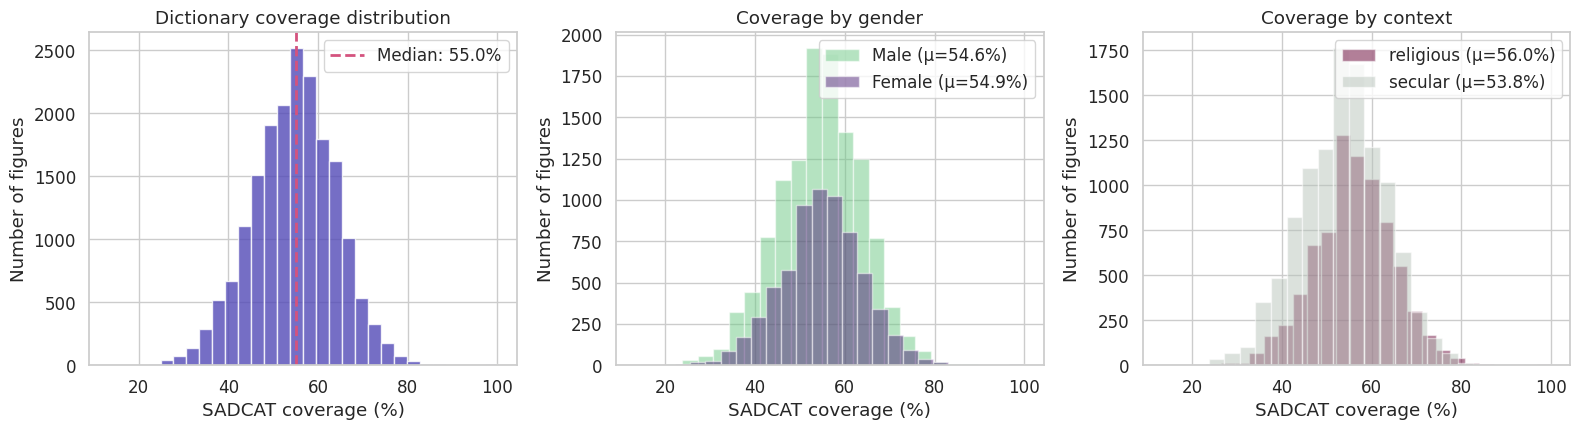

Coverage stats:
  Mean: 54.7%
  Median: 55.0%
  Min: 13.3%
  Zero coverage: 0
  Below 25%: 20 (0.1%)


In [33]:
# ── B1. Coverage distribution ──
dfa = figures[figures['gender'].isin(['Male', 'Female'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Coverage histogram
axes[0].hist(dfa['coverage_pct'].dropna(), bins=30, color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].axvline(dfa['coverage_pct'].median(), color='#D4537E', ls='--', lw=2,
               label=f"Median: {dfa['coverage_pct'].median():.1f}%")
axes[0].set_xlabel('SADCAT coverage (%)')
axes[0].set_ylabel('Number of figures')
axes[0].set_title('Dictionary coverage distribution')
axes[0].legend()

# Coverage by gender
for g, color in COLORS.items():
    if g == 'Unknown': continue
    sub = dfa[dfa['gender'] == g]['coverage_pct'].dropna()
    axes[1].hist(sub, bins=25, alpha=0.5, color=color, label=f"{g} (μ={sub.mean():.1f}%)", edgecolor='white')
axes[1].set_xlabel('SADCAT coverage (%)')
axes[1].set_ylabel('Number of figures')
axes[1].set_title('Coverage by gender')
axes[1].legend()

# Coverage by context
for ctx, color in CTX_COLORS.items():
    sub = dfa[dfa['context'] == ctx]['coverage_pct'].dropna()
    axes[2].hist(sub, bins=25, alpha=0.5, color=color, label=f"{ctx} (μ={sub.mean():.1f}%)", edgecolor='white')
axes[2].set_xlabel('SADCAT coverage (%)')
axes[2].set_ylabel('Number of figures')
axes[2].set_title('Coverage by context')
axes[2].legend()

plt.tight_layout()
savefig(fig, 'V02_coverage_distributions')
plt.show()

print(f"Coverage stats:")
print(f"  Mean: {dfa['coverage_pct'].mean():.1f}%")
print(f"  Median: {dfa['coverage_pct'].median():.1f}%")
print(f"  Min: {dfa['coverage_pct'].min():.1f}%")
print(f"  Zero coverage: {(dfa['coverage_pct'] == 0).sum()}")
print(f"  Below 25%: {(dfa['coverage_pct'] < 25).sum()} ({(dfa['coverage_pct'] < 25).mean()*100:.1f}%)")

  Saved: ../figures/V03_coverage_density.png


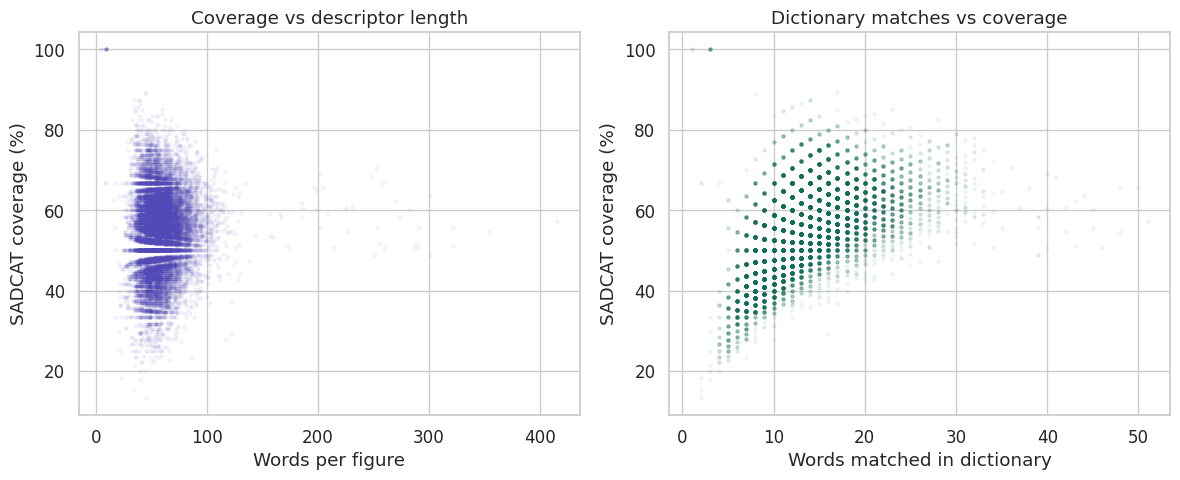

In [34]:
# ── B2. Coverage vs descriptor density ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Word count vs coverage
axes[0].scatter(dfa['word_count'], dfa['coverage_pct'], alpha=0.05, s=5, color='#534AB7')
axes[0].set_xlabel('Words per figure')
axes[0].set_ylabel('SADCAT coverage (%)')
axes[0].set_title('Coverage vs descriptor length')

# Number of SADCAT-matched words vs warmth score reliability
axes[1].scatter(dfa['n_in_dict'], dfa['coverage_pct'], alpha=0.05, s=5, color='#0F6E56')
axes[1].set_xlabel('Words matched in dictionary')
axes[1].set_ylabel('SADCAT coverage (%)')
axes[1].set_title('Dictionary matches vs coverage')

plt.tight_layout()
savefig(fig, 'V03_coverage_density')
plt.show()

  Saved: ../figures/V04_coverage_sensitivity.png


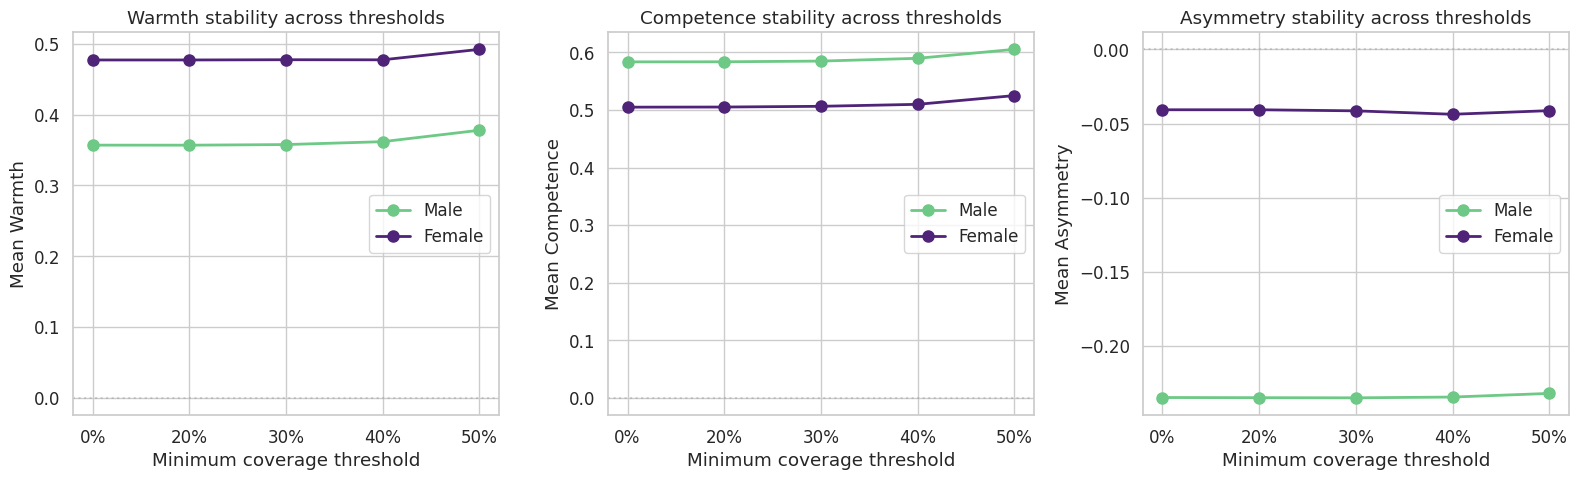

Sensitivity table:
threshold gender     n  warmth  competence  asymmetry
       0%   Male 12005   0.357       0.584     -0.235
       0% Female  6756   0.477       0.505     -0.041
      20%   Male 12002   0.357       0.584     -0.235
      20% Female  6755   0.477       0.505     -0.041
      30%   Male 11926   0.358       0.585     -0.235
      30% Female  6720   0.477       0.506     -0.041
      40%   Male 11265   0.362       0.590     -0.234
      40% Female  6414   0.477       0.510     -0.044
      50%   Male  8849   0.378       0.605     -0.232
      50% Female  5106   0.492       0.525     -0.041


In [35]:
# ── B3. Sensitivity: do results change with coverage threshold? ──
thresholds = [0, 20, 30, 40, 50]

sens_data = []
for thresh in thresholds:
    sub = dfa[dfa['coverage_pct'] >= thresh]
    for g in ['Male', 'Female']:
        gsub = sub[sub['gender'] == g]
        sens_data.append({
            'threshold': f"{thresh}%",
            'gender': g,
            'n': len(gsub),
            'warmth': gsub['dirmean_Warmth'].mean(),
            'competence': gsub['dirmean_Competence'].mean(),
            'asymmetry': gsub['asymmetry'].mean(),
        })

sens_df = pd.DataFrame(sens_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, title) in enumerate([('warmth', 'Warmth'), ('competence', 'Competence'), ('asymmetry', 'Asymmetry')]):
    for g in ['Male', 'Female']:
        sub = sens_df[sens_df['gender'] == g]
        axes[i].plot(sub['threshold'], sub[col], 'o-', color=COLORS[g], label=g, lw=2, markersize=8)
    axes[i].set_xlabel('Minimum coverage threshold')
    axes[i].set_ylabel(f'Mean {title}')
    axes[i].set_title(f'{title} stability across thresholds')
    axes[i].legend()
    axes[i].axhline(0, color='gray', ls=':', alpha=0.3)

plt.tight_layout()
savefig(fig, 'V04_coverage_sensitivity')
plt.show()

print("Sensitivity table:")
print(sens_df.round(3).to_string(index=False))

---
## C. SCM Triangulation: VLM-Derived vs Museum-Text-Derived Scores

Comparing SADCAT scores from two independent measurement paths:
- **VLM path:** Image → Qwen2.5-VL → English descriptors → SADCAT (English dictionary)
- **Museum path:** Curator text (Spanish) → SADCAT (Spanish dictionary)

Agreement across languages and methods is strong evidence of measurement validity.

In [36]:
# ── C1. Aggregate Qwen figure scores to artwork level ──
# Average all figures' scores per artwork to get artwork-level VLM scores
vlm_artwork = dfa.groupby('cat_no').agg(
    vlm_warmth=('dirmean_Warmth', 'mean'),
    vlm_competence=('dirmean_Competence', 'mean'),
    vlm_asymmetry=('asymmetry', 'mean'),
    vlm_sociability=('dirmean_Sociability', 'mean'),
    vlm_morality=('dirmean_Morality', 'mean'),
    vlm_ability=('dirmean_Ability', 'mean'),
    vlm_assertiveness=('dirmean_Assertiveness', 'mean'),
    vlm_status=('dirmean_Status', 'mean'),
    vlm_n_figures=('cat_no', 'count'),
    vlm_coverage=('coverage_pct', 'mean'),
).reset_index()

print(f"VLM artwork-level scores: {len(vlm_artwork)}")

VLM artwork-level scores: 6093


In [37]:
# ── C2. Prepare museum SADCAT scores ──
museum = museum_sadcat[['cat_no', 'dirmean_Warmth', 'dirmean_Competence',
                         'dirmean_Sociability', 'dirmean_Morality',
                         'dirmean_Ability', 'dirmean_Status',
                         'cov_pct_global', 'n_descriptores_fila',
                         'n_en_diccionario_fila']].copy()

museum.columns = ['cat_no', 'mus_warmth', 'mus_competence',
                  'mus_sociability', 'mus_morality',
                  'mus_ability', 'mus_status',
                  'mus_coverage', 'mus_n_descriptors', 'mus_n_in_dict']

museum['mus_asymmetry'] = museum['mus_warmth'] - museum['mus_competence']

print(f"Museum artwork-level scores: {len(museum)}")
print(f"Museum scores with warmth: {museum['mus_warmth'].notna().sum()}")

Museum artwork-level scores: 6888
Museum scores with warmth: 5314


In [38]:
# ── C3. Merge VLM and museum scores ──
triangulation = vlm_artwork.merge(museum, on='cat_no', how='inner')

# Drop rows where either source has no warmth/competence
tri = triangulation.dropna(subset=['vlm_warmth', 'vlm_competence',
                                     'mus_warmth', 'mus_competence']).copy()

print(f"Artworks with both VLM and museum SADCAT scores: {len(tri)}")
print(f"  (from {len(vlm_artwork)} VLM and {len(museum)} museum)")

Artworks with both VLM and museum SADCAT scores: 3954
  (from 6093 VLM and 6888 museum)


In [39]:
# ── C4. Correlations ──
dim_pairs = [
    ('vlm_warmth', 'mus_warmth', 'Warmth'),
    ('vlm_competence', 'mus_competence', 'Competence'),
    ('vlm_asymmetry', 'mus_asymmetry', 'Asymmetry (W−C)'),
    ('vlm_sociability', 'mus_sociability', 'Sociability'),
    ('vlm_morality', 'mus_morality', 'Morality'),
    ('vlm_ability', 'mus_ability', 'Ability'),
    ('vlm_status', 'mus_status', 'Status'),
]

print("Correlation: VLM-derived vs Museum-text-derived SADCAT scores")
print(f"{'Dimension':<18} {'Pearson r':>10} {'p-value':>10} {'Spearman ρ':>12} {'p-value':>10} {'n':>6}")
print("-" * 70)

corr_data = []
for vlm_col, mus_col, dim_name in dim_pairs:
    valid_pair = tri[[vlm_col, mus_col]].dropna()
    if len(valid_pair) > 10:
        r, p_r = stats.pearsonr(valid_pair[vlm_col], valid_pair[mus_col])
        rho, p_rho = stats.spearmanr(valid_pair[vlm_col], valid_pair[mus_col])
        n = len(valid_pair)
        print(f"{dim_name:<18} {r:>10.3f} {p_r:>10.2e} {rho:>12.3f} {p_rho:>10.2e} {n:>6}")
        corr_data.append({'dimension': dim_name, 'pearson_r': r, 'spearman_rho': rho, 'n': n})

corr_df = pd.DataFrame(corr_data)

Correlation: VLM-derived vs Museum-text-derived SADCAT scores
Dimension           Pearson r    p-value   Spearman ρ    p-value      n
----------------------------------------------------------------------
Warmth                  0.104   4.59e-11        0.113   8.51e-13   3954
Competence              0.001   9.72e-01       -0.004   8.12e-01   3954
Asymmetry (W−C)         0.055   5.09e-04        0.066   3.31e-05   3954
Sociability             0.066   4.69e-04        0.084   7.96e-06   2800
Morality                0.087   1.54e-07        0.095   1.20e-08   3594
Ability                -0.024   1.49e-01       -0.047   5.46e-03   3544
Status                  0.032   6.46e-02       -0.002   9.17e-01   3373


  Saved: ../figures/V05_triangulation_scatter.png


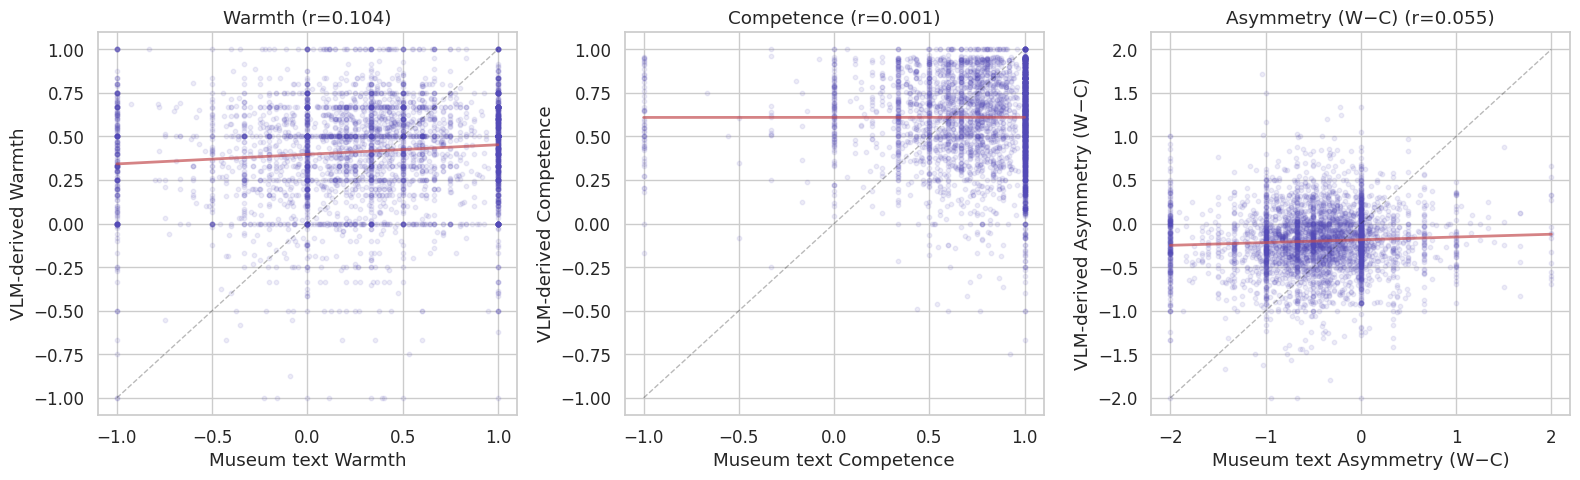

In [40]:
# ── C5. Scatter plots: VLM vs Museum scores ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

main_dims = [
    ('vlm_warmth', 'mus_warmth', 'Warmth'),
    ('vlm_competence', 'mus_competence', 'Competence'),
    ('vlm_asymmetry', 'mus_asymmetry', 'Asymmetry (W−C)'),
]

for i, (vlm_col, mus_col, dim_name) in enumerate(main_dims):
    valid_pair = tri[[vlm_col, mus_col]].dropna()
    r, _ = stats.pearsonr(valid_pair[vlm_col], valid_pair[mus_col])
    
    axes[i].scatter(valid_pair[mus_col], valid_pair[vlm_col],
                   alpha=0.1, s=10, color='#534AB7')
    
    # Regression line
    z = np.polyfit(valid_pair[mus_col], valid_pair[vlm_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid_pair[mus_col].min(), valid_pair[mus_col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', lw=2, alpha=0.7)
    
    # Diagonal
    lims = [min(valid_pair[mus_col].min(), valid_pair[vlm_col].min()),
            max(valid_pair[mus_col].max(), valid_pair[vlm_col].max())]
    axes[i].plot(lims, lims, 'k--', alpha=0.3, lw=1)
    
    axes[i].set_xlabel(f'Museum text {dim_name}')
    axes[i].set_ylabel(f'VLM-derived {dim_name}')
    axes[i].set_title(f'{dim_name} (r={r:.3f})')

plt.tight_layout()
savefig(fig, 'V05_triangulation_scatter')
plt.show()

  Saved: ../figures/V06_distribution_comparison.png


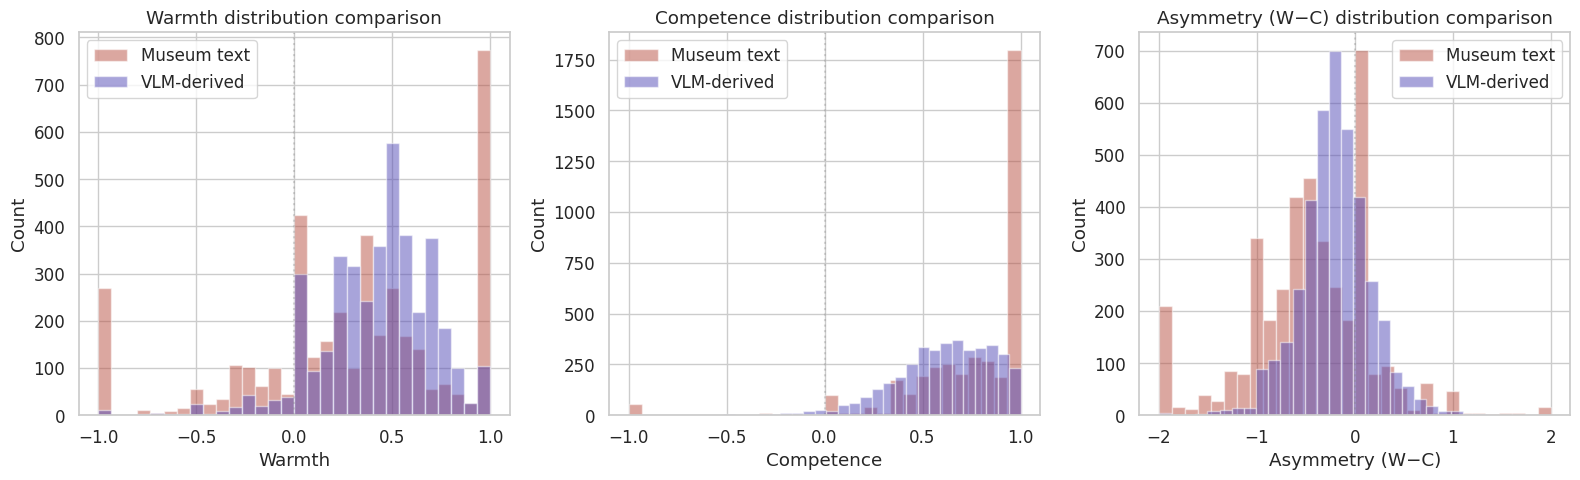


Kolmogorov-Smirnov tests (VLM vs Museum distributions):
  Warmth: KS=0.210, p=7.82e-77
  Competence: KS=0.422, p=1.56e-316
  Asymmetry (W−C): KS=0.297, p=1.25e-154


In [41]:
# ── C6. Distribution comparison: VLM vs Museum ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (vlm_col, mus_col, dim_name) in enumerate(main_dims):
    axes[i].hist(tri[mus_col].dropna(), bins=30, alpha=0.5, color='#B85042',
                label='Museum text', edgecolor='white')
    axes[i].hist(tri[vlm_col].dropna(), bins=30, alpha=0.5, color='#534AB7',
                label='VLM-derived', edgecolor='white')
    axes[i].set_xlabel(dim_name)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{dim_name} distribution comparison')
    axes[i].legend()
    axes[i].axvline(0, color='gray', ls=':', alpha=0.3)

plt.tight_layout()
savefig(fig, 'V06_distribution_comparison')
plt.show()

# KS test for distribution similarity
print("\nKolmogorov-Smirnov tests (VLM vs Museum distributions):")
for vlm_col, mus_col, dim_name in main_dims:
    valid_vlm = tri[vlm_col].dropna()
    valid_mus = tri[mus_col].dropna()
    ks_stat, ks_p = stats.ks_2samp(valid_vlm, valid_mus)
    print(f"  {dim_name}: KS={ks_stat:.3f}, p={ks_p:.2e}")

In [42]:
# ── C7. Systematic bias: mean difference VLM vs Museum ──
print("Systematic differences (VLM minus Museum):")
print(f"{'Dimension':<18} {'VLM mean':>10} {'Museum mean':>12} {'Diff':>8} {'t-stat':>8} {'p-value':>10}")
print("-" * 70)

for vlm_col, mus_col, dim_name in dim_pairs:
    valid_pair = tri[[vlm_col, mus_col]].dropna()
    if len(valid_pair) > 10:
        vlm_mean = valid_pair[vlm_col].mean()
        mus_mean = valid_pair[mus_col].mean()
        diff = vlm_mean - mus_mean
        t, p = stats.ttest_rel(valid_pair[vlm_col], valid_pair[mus_col])
        print(f"{dim_name:<18} {vlm_mean:>10.3f} {mus_mean:>12.3f} {diff:>+8.3f} {t:>8.2f} {p:>10.2e}")

Systematic differences (VLM minus Museum):
Dimension            VLM mean  Museum mean     Diff   t-stat    p-value
----------------------------------------------------------------------
Warmth                  0.413        0.288   +0.125    13.38   6.16e-40
Competence              0.610        0.758   -0.148   -21.98  3.75e-101
Asymmetry (W−C)        -0.201       -0.470   +0.269    23.83  2.08e-117
Sociability             0.580        0.275   +0.305    23.70  2.44e-113
Morality                0.232        0.294   -0.062    -5.38   7.72e-08
Ability                 0.845        0.823   +0.022     3.69   2.32e-04
Status                  0.846        0.793   +0.053     7.31   3.29e-13


In [43]:
# ── C8. Does the VLM preserve the SAME gender pattern as museum text? ──
# This is the most important triangulation test:
# If both sources show females higher in warmth and lower in competence,
# the measurement paths converge despite language/method differences.

# Add context info
conn = sqlite3.connect(DB_PATH)
ctx = pd.read_sql_query("SELECT cat_no, is_religious FROM artwork", conn)
conn.close()

# Add dominant gender from Qwen
tri_ctx = tri.merge(ctx, on='cat_no').merge(
    artwork_qwen_both[['cat_no', 'qwen_gender']], on='cat_no'
)

# Compare: mean scores by dominant gender — do both sources agree?
print("Mean scores by artwork dominant gender:")
print(f"\n{'Source':<12} {'Gender':<8} {'Warmth':>8} {'Competence':>12} {'Asymmetry':>10} {'n':>6}")
print("-" * 60)

for gender in ['Male', 'Female']:
    sub = tri_ctx[tri_ctx['qwen_gender'] == gender]
    # VLM scores
    print(f"{'VLM':<12} {gender:<8} {sub['vlm_warmth'].mean():>8.3f} {sub['vlm_competence'].mean():>12.3f} {sub['vlm_asymmetry'].mean():>10.3f} {len(sub):>6}")
    # Museum scores
    print(f"{'Museum':<12} {gender:<8} {sub['mus_warmth'].mean():>8.3f} {sub['mus_competence'].mean():>12.3f} {sub['mus_asymmetry'].mean():>10.3f} {len(sub):>6}")

Mean scores by artwork dominant gender:

Source       Gender     Warmth   Competence  Asymmetry      n
------------------------------------------------------------
VLM          Male        0.401        0.715     -0.315   1509
Museum       Male        0.272        0.772     -0.500   1509
VLM          Female      0.412        0.607     -0.195    588
Museum       Female      0.280        0.768     -0.488    588


  Saved: ../figures/V07_gender_pattern_triangulation.png


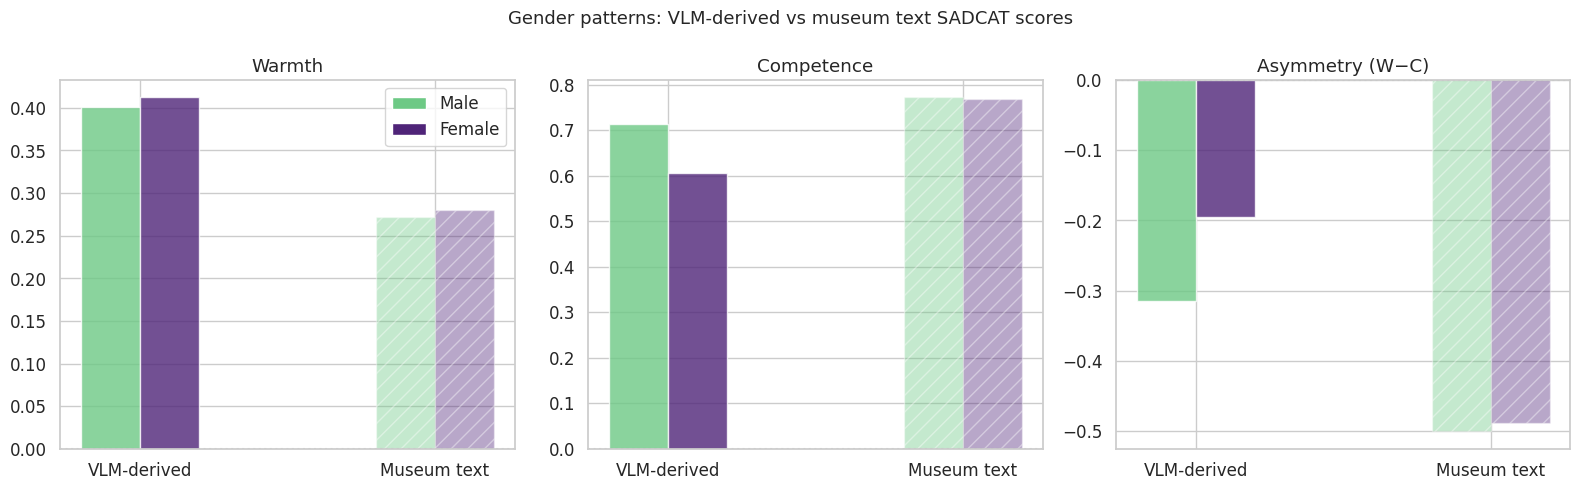

In [44]:
# ── C9. Bar chart: VLM vs Museum gender patterns side by side ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (vlm_col, mus_col, dim_name) in enumerate(main_dims):
    x = np.arange(2)
    w = 0.2
    
    for j, gender in enumerate(['Male', 'Female']):
        sub = tri_ctx[tri_ctx['qwen_gender'] == gender]
        vlm_val = sub[vlm_col].mean()
        mus_val = sub[mus_col].mean()
        
        axes[i].bar(x[0] + j*w, vlm_val, w, color=COLORS[gender],
                   alpha=0.8, edgecolor='white')
        axes[i].bar(x[1] + j*w, mus_val, w, color=COLORS[gender],
                   alpha=0.4, edgecolor='white', hatch='//')
    
    axes[i].set_xticks(x + w/2)
    axes[i].set_xticklabels(['VLM-derived', 'Museum text'])
    axes[i].set_title(dim_name)
    axes[i].axhline(0, color='gray', ls=':', alpha=0.3)
    
    if i == 0:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=COLORS['Male'], label='Male'),
            Patch(facecolor=COLORS['Female'], label='Female'),
        ]
        axes[i].legend(handles=legend_elements)

fig.suptitle('Gender patterns: VLM-derived vs museum text SADCAT scores', fontsize=13)
plt.tight_layout()
savefig(fig, 'V07_gender_pattern_triangulation')
plt.show()

---
## Summary

In [45]:
# ── Final validation summary ──
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)

print(f"\nA. Gender Assignment Accuracy")
print(f"   Artworks compared: {len(valid)}")
print(f"   Exact match accuracy: {exact_match:.1%}")
print(f"   Cohen's κ: {kappa:.3f}")

print(f"\nB. SADCAT Coverage Audit")
print(f"   Mean coverage: {dfa['coverage_pct'].mean():.1f}%")
print(f"   Zero coverage figures: {(dfa['coverage_pct'] == 0).sum()}")
print(f"   Below 25% coverage: {(dfa['coverage_pct'] < 25).mean()*100:.1f}%")

print(f"\nC. SCM Triangulation")
print(f"   Artworks with both sources: {len(tri)}")
for row in corr_data:
    if row['dimension'] in ['Warmth', 'Competence', 'Asymmetry (W−C)']:
        print(f"   {row['dimension']}: r={row['pearson_r']:.3f}, ρ={row['spearman_rho']:.3f}")

print(f"\n" + "=" * 60)

VALIDATION SUMMARY

A. Gender Assignment Accuracy
   Artworks compared: 4301
   Exact match accuracy: 57.6%
   Cohen's κ: 0.355

B. SADCAT Coverage Audit
   Mean coverage: 54.7%
   Zero coverage figures: 0
   Below 25% coverage: 0.1%

C. SCM Triangulation
   Artworks with both sources: 3954
   Warmth: r=0.104, ρ=0.113
   Competence: r=0.001, ρ=-0.004
   Asymmetry (W−C): r=0.055, ρ=0.066

